In [40]:
import pandas as pd 

df = pd.read_csv("../data/processed_data.csv")
df.head()

,title,text,subject,date,label,text_length,year,clean_text,tokens,final_text
0,White House says Flynn's Russia plea implicate...,WASHINGTON (Reuters) - The guilty plea entered...,politicsNews,NaN,1,713,NaN,washington reuters the guilty plea entered by ...,"['washington', 'reuters', 'guilty', 'plea', 'e...",washington reuters guilty plea entered u s nat...
1,Brigitte Gabriel Reveals Muslim Brotherhood “P...,"Brigitte Gabriel is a Christian who, after bei...",politics,2017-02-12,0,3456,2017.0,brigitte gabriel is a christian who after bein...,"['brigitte', 'gabriel', 'christian', 'terroriz...",brigitte gabriel christian terrorized muslim e...
2,'We are one': Palestinian Christians and Musli...,JERUSALEM (Reuters) - Less than an hour after ...,worldnews,NaN,1,3720,NaN,jerusalem reuters less than an hour after u s ...,"['jerusalem', 'reuters', 'hour', 'u', 's', 'pr...",jerusalem reuters hour u s president donald tr...
3,WATCH: Pretty College Age Girl Stun Illegal Al...,It looks like we re not the only ones who are ...,politics,2015-09-16,0,363,2015.0,it looks like we re not the only ones who are ...,"['looks', 'like', 'ones', 'fed', 'people', 'pr...",looks like ones fed people protesting defend l...
4,Twitter Is Merciless With Rush Limbaugh’s Tho...,The controversy surrounding the Cincinnati Zoo...,News,NaN,0,3087,NaN,the controversy surrounding the cincinnati zoo...,"['controversy', 'surrounding', 'cincinnati', '...",controversy surrounding cincinnati zoo s decis...


In [2]:
X = df['final_text'].fillna('').astype(str)
y = df['label']

### Logistic Regression Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size= 0.2, random_state= 42
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
vertorizer = TfidfVectorizer(max_features= 5000, ngram_range=(1,2))

In [6]:
X_train_tfidf = vertorizer.fit_transform(X_train)

In [7]:
X_test_tfidf = vertorizer.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred = model.predict(X_test_tfidf)

In [10]:
from sklearn.metrics import classification_report, accuracy_score

In [11]:
print("Accuracy : ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy :  0.973
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       538
           1       0.96      0.98      0.97       462

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [12]:
from sklearn.metrics import confusion_matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[521  17]
 [ 10 452]]


In [21]:
import pickle

pickle.dump(model, open("../models/logistic_model.pkl", "wb"))
pickle.dump(vertorizer,open("../models/vectorizer.pkl", "wb"))

In [25]:
model = pickle.load(open("../models/logistic_model.pkl", "rb"))
vertorizer = pickle.load(open("../models/vectorizer.pkl", "rb"))

def predict_news(text):
  vec = vertorizer.transform([text])
  pred = model.predict(vec)

  return "Fake News" if pred[0] == 1 else "Real News"

In [26]:
print(predict_news("Breaking: Government announces new scheme"))
print(predict_news("Aliens landed in Delhi yesterday"))

Real News
Real News


### Naive Bayes Model

In [27]:
from sklearn.naive_bayes import MultinomialNB

In [28]:
nb_model = MultinomialNB()

In [29]:
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [30]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.93      0.95      0.94       538
           1       0.94      0.92      0.93       462

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [34]:
print(confusion_matrix(y_test, y_pred_nb))

[[510  28]
 [ 39 423]]


In [43]:
import pickle

with open("../models/nb_model.pkl", "wb") as f:
  pickle.dump(nb_model,f)

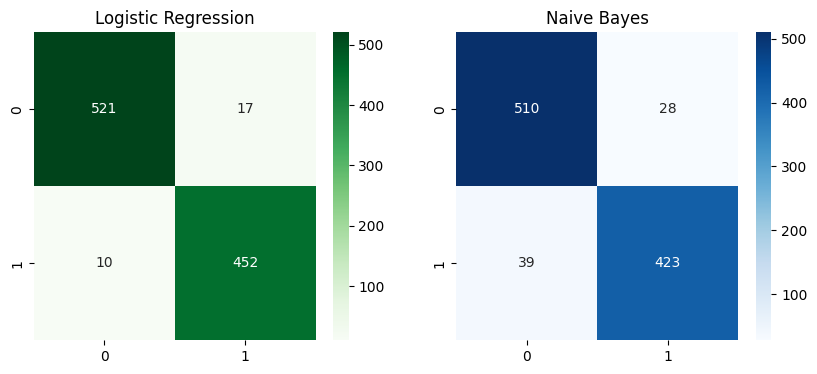

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)

cm_logistic = np.array([[521, 17],
                        [10, 452]])

cm_nb = np.array([[510, 28],
                  [39, 423]])

plt.figure(figsize=(10, 4))

# Logistic
plt.subplot(1, 2, 1)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression")

# Naive Bayes
plt.subplot(1, 2, 2)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes")

plt.savefig("outputs/confusion_matrix.png")

plt.show()